In [9]:
%pip install python-calamine

   ---------------------------------------- 0.0/692.6 kB ? eta -:--:--
   ---------------------------------------- 692.6/692.6 kB 5.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
#0
import pandas as pd

base_path = r'C:\Users\AYUSH ADITYA\OneDrive\Desktop\Major project\California Design documents'

files = [
    'Sponsored_Products_Advertised_product_report',
    'Sponsored_Products_Search_term_report',
    'Sponsored_Products_Targeting_report',
]

for filename in files:
    xlsx_path = f'{base_path}\\{filename}.xlsx'
    csv_path = f'{base_path}\\{filename}_clean.csv'

    print(f'Converting {filename}...', end=' ')

    # Read binary stream to bypass OneDrive file lock
    with open(xlsx_path, 'rb') as f:
        df = pd.read_excel(f, engine='calamine')

    # Export cleanly with utf-8-sig encoding
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print('Done!')

Converting Sponsored_Products_Advertised_product_report... Done!
Converting Sponsored_Products_Search_term_report... Done!
Converting Sponsored_Products_Targeting_report... Done!


In [25]:
import pandas as pd

base_path = r'C:\Users\AYUSH ADITYA\OneDrive\Desktop\Major project\California Design documents'

adv = pd.read_csv(
    f'{base_path}\\Sponsored_Products_Advertised_product_report_clean.csv',
    low_memory=False,
)
st = pd.read_csv(
    f'{base_path}\\Sponsored_Products_Search_term_report_clean.csv',
    low_memory=False,
)
tgt = pd.read_csv(
    f'{base_path}\\Sponsored_Products_Targeting_report_clean.csv',
    low_memory=False,
)

print('All reports loaded cleanly!')
print('Search Term shape:', st.shape)

All reports loaded cleanly!
Search Term shape: (315699, 26)


In [26]:

# Strip leading/trailing whitespaces from column names across all datasets
for df in [adv, st, tgt]:
    df.columns = df.columns.str.strip()

# Run sanity check with safe datetime conversion
for name, df in [('Advertised', adv), ('SearchTerm', st), ('Targeting', tgt)]:
    print(f'=== {name} Report ===')
    print('Shape:', df.shape)

    # Convert Date column safely to Datetime
    if 'Date' in df.columns:
        date_col = pd.to_datetime(df['Date'], errors='coerce')
        print(f'Date Range: {date_col.min().date()} -> {date_col.max().date()}')

    # Print Country and Currency cleanly
    country = df['Country'].dropna().unique() if 'Country' in df.columns else 'N/A'
    currency = (
        df['Currency'].dropna().unique() if 'Currency' in df.columns else 'N/A'
    )

    print(f'Country: {country} | Currency: {currency}')
    print('-' * 40)

=== Advertised Report ===
Shape: (410301, 24)
Date Range: 2026-07-01 -> 2026-07-30
Country: ['United States'] | Currency: ['USD']
----------------------------------------
=== SearchTerm Report ===
Shape: (315699, 26)
Country: ['United States'] | Currency: ['USD']
----------------------------------------
=== Targeting Report ===
Shape: (16158, 26)
Country: ['United States'] | Currency: ['USD']
----------------------------------------


In [28]:
#1.1 Account-level KPIs (Table 1)
total_spend  = adv['Spend'].sum()
total_sales  = adv['7 Day Total Sales'].sum()
total_orders = adv['7 Day Total Orders (#)'].sum()
total_clicks = adv['Clicks'].sum()
total_impr   = adv['Impressions'].sum()
total_units = adv['7 Day Total Units (#)'].sum()
acos = total_spend / total_sales
roas = total_sales / total_spend
ctr  = total_clicks / total_impr
cvr  = total_orders / total_clicks       # orders per click
cpc  = total_spend / total_clicks
 
print(f"Spend {total_spend:,.0f}  Sales {total_sales:,.0f}")
print(f"Orders {total_orders:,.0f}  Clicks {total_clicks:,.0f}")
print(f"Units {total_units:,.0f}")
print(f"ACOS {acos:.1%}  ROAS {roas:.2f}x  CTR {ctr:.2%}  CVR {cvr:.2%}  CPC {cpc:.2f}")


Spend 1,479,163  Sales 5,445,552
Orders 97,644  Clicks 620,891
Units 110,411
ACOS 27.2%  ROAS 3.68x  CTR 0.46%  CVR 15.73%  CPC 2.38


In [19]:
import numpy as np

# 1. Clean column whitespace and ensure proper datetime format
adv.columns = adv.columns.str.strip()
adv['Date'] = pd.to_datetime(adv['Date'])

# 2. Dynamically match column names (handles variation in ($) or (#) suffixes)
sales_col = [c for c in adv.columns if '7 Day Total Sales' in c][0]
orders_col = [c for c in adv.columns if '7 Day Total Orders' in c][0]

# 3. Daily aggregation
daily = (
    adv.groupby('Date')
    .agg(
        Spend=('Spend', 'sum'),
        Sales=(sales_col, 'sum'),
        Orders=(orders_col, 'sum'),
        Clicks=('Clicks', 'sum'),
        Impressions=('Impressions', 'sum'),
    )
    .reset_index()
    .sort_values('Date')
)

# 4. Safe ratio calculations (replaces inf/nan with 0 when sales or clicks are 0)
daily['ACOS'] = np.where(daily['Sales'] > 0, daily['Spend'] / daily['Sales'], 0)
daily['ROAS'] = np.where(daily['Spend'] > 0, daily['Sales'] / daily['Spend'], 0)
daily['CTR'] = np.where(
    daily['Impressions'] > 0, daily['Clicks'] / daily['Impressions'], 0
)
daily['CVR'] = np.where(
    daily['Clicks'] > 0, daily['Orders'] / daily['Clicks'], 0
)

# Preview results
print("Daily trend table generated successfully!")
print(daily.head())


Daily trend table generated successfully!
        Date     Spend      Sales  Orders  Clicks  Impressions      ACOS  \
0 2026-07-01  36753.09  142003.58    2476   16012      3627236  0.258818   
1 2026-07-02  41015.99  148935.87    2597   17414      4137782  0.275394   
2 2026-07-03  46483.96  153302.11    2680   17408      3906092  0.303218   
3 2026-07-04  38814.22  142183.24    2487   16115      3858116  0.272987   
4 2026-07-05  47439.29  187393.26    3248   19435      5105556  0.253154   

       ROAS       CTR       CVR  
0  3.863718  0.004414  0.154634  
1  3.631166  0.004209  0.149133  
2  3.297957  0.004457  0.153952  
3  3.663174  0.004177  0.154328  
4  3.950170  0.003807  0.167121  


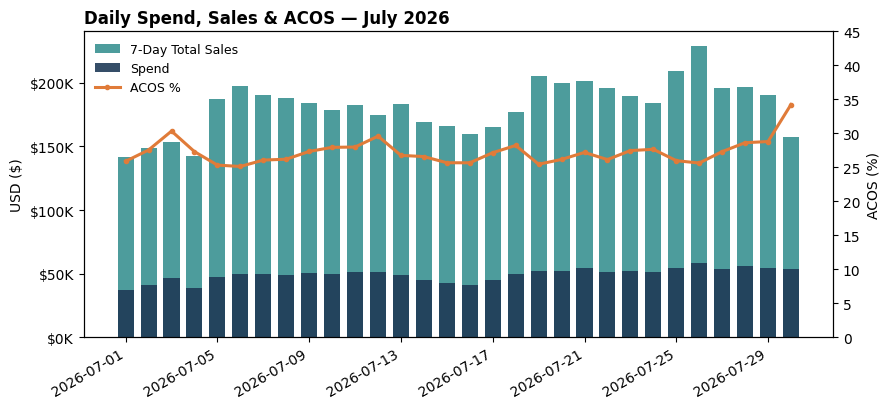

In [20]:
#1.3 Figure 1 — daily spend / sales / ACOS chart
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.bar(daily['Date'], daily['Sales'], color='#2E8B8B', alpha=0.85, label='7-Day Total Sales', width=0.7)
ax1.bar(daily['Date'], daily['Spend'], color='#1F3B57', alpha=0.9, label='Spend', width=0.7)
ax1.set_ylabel('USD ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
 
ax2 = ax1.twinx()
ax2.plot(daily['Date'], daily['ACOS'] * 100, color='#E07B39', linewidth=2.2, marker='o', markersize=3, label='ACOS %')
ax2.set_ylabel('ACOS (%)')
ax2.set_ylim(0, 45)
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, fontsize=9)
ax1.set_title('Daily Spend, Sales & ACOS — July 2026', fontsize=12, fontweight='bold', loc='left')
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('chart1_daily_trend.png', dpi=160)


In [30]:
#2.1 Portfolio-level aggregation (Table 2)
port = adv.groupby('Portfolio name').agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
 
port['ACOS'] = port['Spend'] / port['Sales']
port['ROAS'] = port['Sales'] / port['Spend']
port = port.sort_values('Spend', ascending=False)


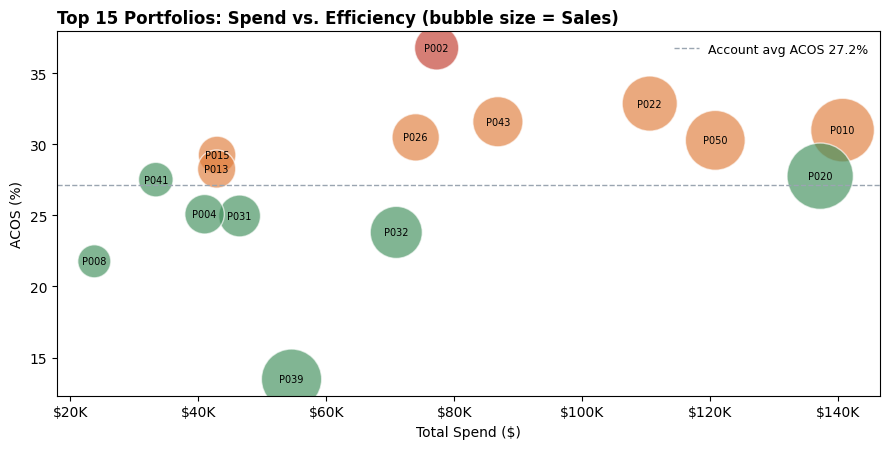

In [31]:
#2.2 Figure 2 — portfolio spend-vs-ACOS bubble chart
top15 = port.head(15)
sizes = (top15['Sales'] / top15['Sales'].max()) * 2200 + 80
colors = ['#C0392B' if a > 0.35 else '#E07B39' if a > 0.28 else '#3E8E5A' for a in top15['ACOS']]
 
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.scatter(top15['Spend'], top15['ACOS'] * 100, s=sizes, c=colors, alpha=0.65, edgecolor='white', linewidth=1)
for _, row in top15.iterrows():
    ax.annotate(row['Portfolio name'].replace('Portfolio_', 'P'),
                (row['Spend'], row['ACOS'] * 100), fontsize=7, ha='center', va='center')
ax.axhline(27.16, color='#9AA5B1', linestyle='--', linewidth=1, label='Account avg ACOS 27.2%')
ax.set_xlabel('Total Spend ($)'); ax.set_ylabel('ACOS (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Top 15 Portfolios: Spend vs. Efficiency (bubble size = Sales)', fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('chart2_portfolio_bubble.png', dpi=160)


In [33]:
#2.3 Campaign-level aggregation & Pareto computation (Figure 3, Table 3 basis)
camp = adv.groupby('Campaign Name').agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
camp['ACOS'] = camp['Spend'] / camp['Sales']
camp['ROAS'] = camp['Sales'] / camp['Spend']
camp = camp.sort_values('Spend', ascending=False).reset_index(drop=True)
 
camp['cum_spend_pct'] = camp['Spend'].cumsum() / camp['Spend'].sum() * 100
camp['cum_sales_pct'] = camp['Sales'].cumsum() / camp['Sales'].sum() * 100
camp['cum_camp_pct']  = (camp.index + 1) / len(camp) * 100
 
# Zero-sale campaigns and their combined spend
zero_sales_camps = camp[camp['Sales'] == 0]
print(len(zero_sales_camps), zero_sales_camps['Spend'].sum())
 
# Top-20%-of-campaigns concentration check
top20 = camp[camp['cum_camp_pct'] <= 20]
print(top20['Spend'].sum() / camp['Spend'].sum(), top20['Sales'].sum() / camp['Sales'].sum())


910 8247.61
0.9019816568796324 0.8983061442949296


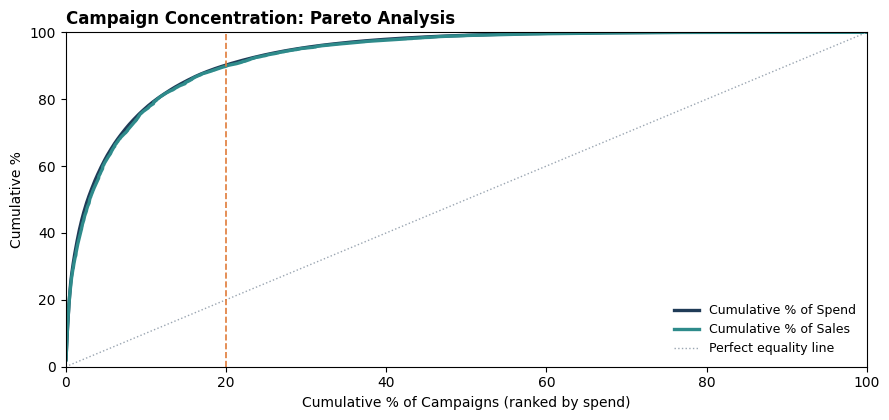

In [34]:
#2.4 Figure 3 — Pareto (cumulative spend % vs. cumulative sales %)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(camp['cum_camp_pct'], camp['cum_spend_pct'], color='#1F3B57', linewidth=2.4, label='Cumulative % of Spend')
ax.plot(camp['cum_camp_pct'], camp['cum_sales_pct'], color='#2E8B8B', linewidth=2.4, label='Cumulative % of Sales')
ax.plot([0, 100], [0, 100], color='#9AA5B1', linestyle=':', linewidth=1, label='Perfect equality line')
ax.axvline(20, color='#E07B39', linestyle='--', linewidth=1.2)
ax.set_xlabel('Cumulative % of Campaigns (ranked by spend)')
ax.set_ylabel('Cumulative %')
ax.set_title('Campaign Concentration: Pareto Analysis', fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('chart3_pareto.png', dpi=160)


In [35]:
#2.5 Pause / scale campaign lists (feeds Report Section 6)
# Underperformers: meaningful spend, ACOS above 50%
high_acos = camp[(camp['Spend'] > 1000) & (camp['ACOS'] > 0.5)].sort_values('Spend', ascending=False)
print(len(high_acos), high_acos['Spend'].sum(), high_acos['Sales'].sum())
 
# Scale candidates: meaningful spend, ACOS under 15%
low_acos = camp[(camp['Spend'] > 1000) & (camp['ACOS'] < 0.15) & (camp['ACOS'] > 0)].sort_values('Spend', ascending=False)
print(len(low_acos), low_acos['Spend'].sum(), low_acos['Sales'].sum())


9 30420.609999999997 52456.8
16 31277.280000000002 304124.79000000004


In [37]:
#3.1 Search-term aggregation and zero-order tiering
term = st.groupby('Customer Search Term').agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
term['ACOS'] = term['Spend'] / term['Sales']
term['ROAS'] = term['Sales'] / term['Spend']
 
wasted = term[term['Orders'] == 0]
print(len(wasted), wasted['Spend'].sum(), wasted['Spend'].sum() / term['Spend'].sum())
 
# Tractability tiers used in Table 3
tier1 = wasted[wasted['Spend'] >= 20]                              # negate individually
tier2 = wasted[(wasted['Spend'] < 20) & (wasted['Spend'] >= 5)]    # batch review
tier3 = wasted[wasted['Spend'] < 5]                                 # long tail, automate
 
for name, t in [('Tier1', tier1), ('Tier2', tier2), ('Tier3', tier3)]:
    print(name, len(t), t['Spend'].sum())


150009 413248.38 0.2798810891154905
Tier1 1018 32398.89
Tier2 16537 133508.7
Tier3 132454 247340.78999999995


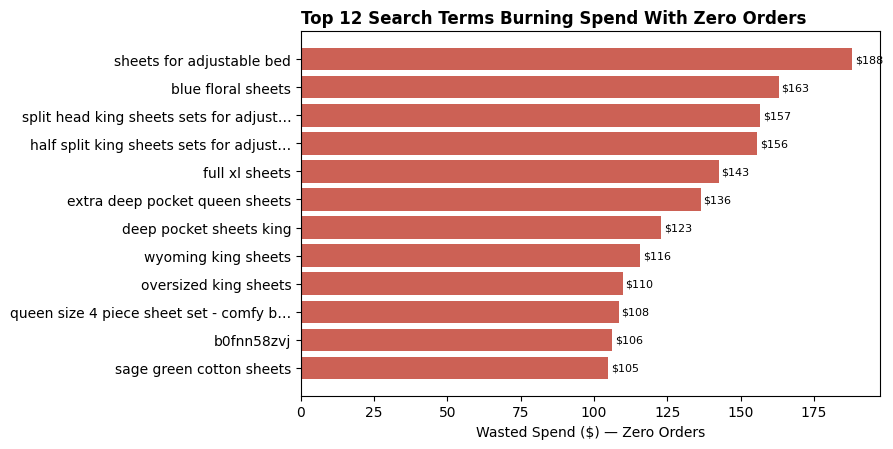

In [38]:
#3.2 Figure 4 — top zero-order search terms by spend
top_wasted = wasted.sort_values('Spend', ascending=False).head(12)
labels = [t[:38] + '…' if len(t) > 38 else t for t in top_wasted['Customer Search Term']]
 
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(labels[::-1], top_wasted['Spend'][::-1], color='#C0392B', alpha=0.8)
ax.set_xlabel('Wasted Spend ($) — Zero Orders')
ax.set_title('Top 12 Search Terms Burning Spend With Zero Orders', fontsize=12, fontweight='bold', loc='left')
for i, v in enumerate(top_wasted['Spend'][::-1]):
    ax.text(v + 1, i, f'${v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('chart4_wasted_terms.png', dpi=160)


In [40]:
#3.3 Match-type performance (Table 4)
mt = st.groupby('Match Type').agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
mt['ACOS'] = mt['Spend'] / mt['Sales']
mt['ROAS'] = mt['Sales'] / mt['Spend']
mt['CTR']  = mt['Clicks'] / mt['Impressions']
mt['CVR']  = mt['Orders'] / mt['Clicks']
# Match Type '-' rows are auto-targeted placements with no keyword match type


In [41]:
#4.1 Targeting-type classification
def classify(row):
    t = str(row['Targeting'])
    if t.startswith('asin='):
        return 'Product (ASIN) Targeting'
    elif t in ['close-match', 'loose-match', 'substitutes', 'complements']:
        return f'Auto - {t}'
    else:
        return 'Keyword Targeting'
 
tgt['Targeting_Type'] = tgt.apply(classify, axis=1)
 
grp = tgt.groupby('Targeting_Type').agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
grp['ACOS'] = grp['Spend'] / grp['Sales']
grp['ROAS'] = grp['Sales'] / grp['Spend']
grp = grp.sort_values('Spend', ascending=False)


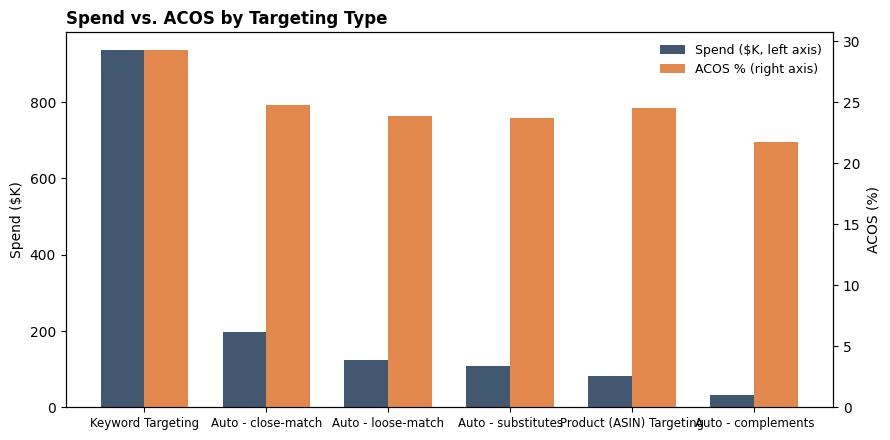

In [43]:
#4.2 Figure 5 — spend vs. ACOS by targeting type
import numpy as np
x = np.arange(len(grp))
 
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(x - 0.18, grp['Spend'] / 1000, width=0.36, color='#1F3B57', alpha=0.85, label='Spend ($K, left axis)')
ax1.set_ylabel('Spend ($K)')
ax1.set_xticks(x); ax1.set_xticklabels(grp['Targeting_Type'], fontsize=8.5, rotation=0)
 
ax2 = ax1.twinx()
ax2.bar(x + 0.18, grp['ACOS'] * 100, width=0.36, color='#E07B39', alpha=0.9, label='ACOS % (right axis)')
ax2.set_ylabel('ACOS (%)')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False, fontsize=9)
ax1.set_title('Spend vs. ACOS by Targeting Type', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('chart5_targeting_type.png', dpi=160)


In [45]:
#4.3 Top-of-search impression-share bucketing
tgt2 = tgt[tgt['Top-of-search Impression Share'].notna() & (tgt['Impressions'] > 0)].copy()
 
tgt2['TOS_bucket'] = pd.cut(
    tgt2['Top-of-search Impression Share'],
    bins=[-0.01, 0, 0.1, 0.25, 0.5, 1.01],
    labels=['0%', '0-10%', '10-25%', '25-50%', '50-100%']
)
 
# Pass observed=False to keep the current behavior and silence the warning
tos = tgt2.groupby('TOS_bucket', observed=False).agg(
    Spend=('Spend', 'sum'),
    Sales=('7 Day Total Sales', 'sum'),
    Orders=('7 Day Total Orders (#)', 'sum'),
    Clicks=('Clicks', 'sum'),
    Impressions=('Impressions', 'sum')
).reset_index()
tos['ACOS'] = tos['Spend'] / tos['Sales']
tos['CVR']  = tos['Orders'] / tos['Clicks']


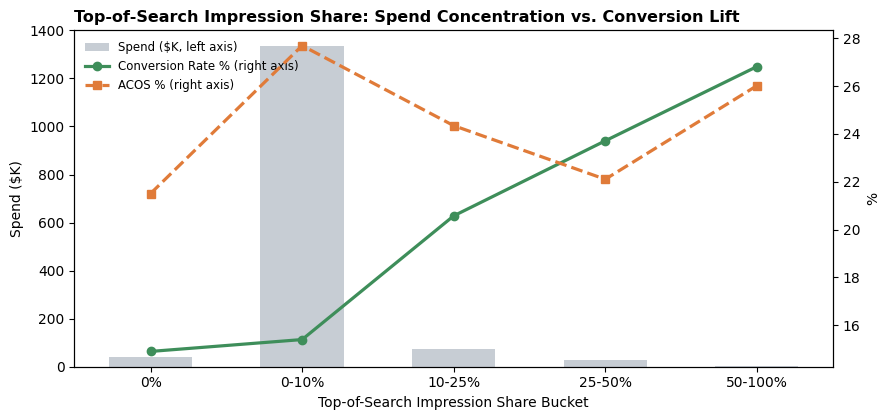

In [46]:
#4.4 Figure 6 — spend concentration vs. conversion lift by TOS bucket
x = np.arange(len(tos))
fig, ax1 = plt.subplots(figsize=(9, 4.3))
ax1.bar(x, tos['Spend'] / 1000, color='#9AA5B1', alpha=0.55, width=0.55, label='Spend ($K, left axis)')
ax1.set_ylabel('Spend ($K)'); ax1.set_xticks(x); ax1.set_xticklabels(tos['TOS_bucket'])
ax1.set_xlabel('Top-of-Search Impression Share Bucket')
 
ax2 = ax1.twinx()
ax2.plot(x, tos['CVR'] * 100, color='#3E8E5A', marker='o', linewidth=2.3, label='Conversion Rate % (right axis)')
ax2.plot(x, tos['ACOS'] * 100, color='#E07B39', marker='s', linewidth=2.3, linestyle='--', label='ACOS % (right axis)')
ax2.set_ylabel('%')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, fontsize=8.5)
ax1.set_title('Top-of-Search Impression Share: Spend Concentration vs. Conversion Lift', fontsize=11.5, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('chart6_tos.png', dpi=160)


In [47]:
#5.1 Actionable-waste total and reallocation-impact estimate
actionable_waste = tier1['Spend'].sum() + tier2['Spend'].sum()
account_roas = total_sales / total_spend   # 3.68x, computed in Section 1.1
 
potential_incremental_sales = actionable_waste * account_roas
print(f"Actionable wasted spend: ${actionable_waste:,.0f}")
print(f"Potential incremental sales at account ROAS: ${potential_incremental_sales:,.0f}")
 
# Combined dollar exposure across Priorities 1-3, for the narrative total (~$200K, ~14% of spend)
combined_exposure = actionable_waste + high_acos['Spend'].sum() + low_acos['Spend'].sum()
print(combined_exposure, combined_exposure / total_spend)


Actionable wasted spend: $165,908
Potential incremental sales at account ROAS: $610,790
227605.48 0.15387453684693642


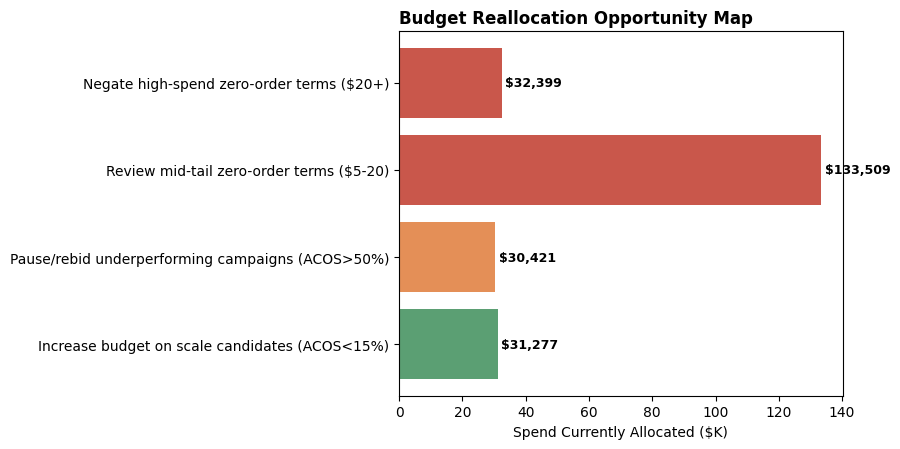

In [48]:
#5.2 Figure 7 — recommendation exposure chart
labels = [
    'Negate high-spend zero-order terms ($20+)',
    'Review mid-tail zero-order terms ($5-20)',
    'Pause/rebid underperforming campaigns (ACOS>50%)',
    'Increase budget on scale candidates (ACOS<15%)'
]
values = [tier1['Spend'].sum(), tier2['Spend'].sum(), high_acos['Spend'].sum(), low_acos['Spend'].sum()]
colors = ['#C0392B', '#C0392B', '#E07B39', '#3E8E5A']
 
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(labels[::-1], np.array(values[::-1]) / 1000, color=colors[::-1], alpha=0.85)
for i, v in enumerate(values[::-1]):
    ax.text(v / 1000 + 1, i, f'${v:,.0f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Spend Currently Allocated ($K)')
ax.set_title('Budget Reallocation Opportunity Map', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('chart7_recommendations.png', dpi=160)
